# Commodity MST Replication - Hard-Threshold Factor Model
## Applied to Combined Commodity Asset Universe (N=130)
### Xavier Jaeger · Bachelor Thesis · Erasmus University Rotterdam

---

Applies the MST (2025) three-pass factor pricing framework to a combined
commodity asset universe consisting of:

| Block | Description | N |
|-------|-------------|---|
| B1 | Commodity futures (Basis/MOM/HP/Value tercile sorts) | 12 |
| B2 | Commodity equities (characteristic-sorted) | 115 |
| B4 | Commodity currencies (beta-sorted) | 3 |
| **Total** | | **130** |

**Key adaptations from MST equity replication:**

| Aspect | MST equity | Commodity |
|--------|-----------|----------|
| Frequency | Monthly | **Monthly (compounded from weekly)** |
| T | 223 | **223** (same period) |
| N | 130 | **130** |
| Threshold | ADBear | **ADBear** (diagnostic confirmed r=-0.31, R²=9.8%) |
| Sample | Feb 1997–Aug 2015 | **Feb 1997–Aug 2015** |
| Pass 3 | RmRf | **BM, MOM, HP, BASIS** |

ADBear is used because it explains 9.8% of commodity equity return variance
(R²=0.097, p<0.001) - more than BCOM (R²=0.0004, p=0.72) at any frequency.
The monotone quintile pattern (-22.5%pa to +26.9%pa) confirms ADBear
captures genuine commodity equity bear market risk.


---
## Section 0 - Imports, Constants & Helpers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import chi2 as chi2_dist
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'serif', 'axes.labelsize': 10,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

# File paths
PATH_RETURNS  = 'Input/test_asset_universe.csv'                  # weekly, N=130
PATH_ADBEAR   = 'Input/ADBear_Monthly_Formation.csv'             # monthly
PATH_MST_RET  = 'Input/mExcess_Returns_Farago_Tedongap_201508_LM.csv'  # for ADBear dates
PATH_FACTORS  = 'Input/pass3_factors.csv'                        # weekly, 4 factors

# Constants (matching MST equity replication)
R_LAG       = 1        # one-month lag for ADBear
N_FACTORS   = 6        # factors per regime
#OOS_FRAC    = 0.40     # 40% OOS  → L_OOS≈89, T_IN≈134
T_MIN       = 20       # minimum months per regime for PCA

# Grid: same as MST equity replication (ADBear in [0, 0.4] step 0.0025)
GRID_LO, GRID_HI, GRID_STEP = 0.0, 0.4, 0.0025



In [2]:
# SHARED HELPERS - identical to MST equity replication

def make_dummies(adbear, theta):
    '''
    Bear (D) = ADBear >= theta  (same convention as MST equity replication)
    Bull (S) = ADBear <  theta
    '''
    d_D = (adbear >= theta).astype(float)
    d_S = (adbear <  theta).astype(float)
    return d_D, d_S


def demean_regime(X, d):
    X_na       = (X * d[:, None]).astype(float)
    X_na[d==0] = np.nan
    mu         = np.nanmean(X_na, axis=0)
    X_dm       = np.nan_to_num(X_na - mu, nan=0.0)
    return X_dm, mu


def pca_loadings(X_dm, k, N):
    evals, evecs = np.linalg.eigh(X_dm.T @ X_dm)
    idx          = np.argsort(evals)[::-1]
    return np.sqrt(N) * evecs[:, idx[:k]]


def pass2_gamma(X_ret_full, B, k, T_j):
    Bk      = B[:, :k]
    BtB_inv = np.linalg.inv(Bk.T @ Bk + 1e-12*np.eye(k))
    Gamma   = BtB_inv @ Bk.T @ X_ret_full.T
    return Gamma.sum(axis=1) / T_j


def compute_rmspe(alpha, N):
    return np.sqrt(alpha @ alpha / N)


def compute_r2(rmspe, R_bar, N, k, NF):
    ss    = R_bar @ R_bar
    r2    = 1 - N*rmspe**2 / ss if ss != 0 else np.nan
    adjr2 = 1 - (1-r2) * N / (N - NF) if ss != 0 else np.nan
    return r2, adjr2


def frisch_waugh_beta(X_boot, F, T_j):
    M    = np.eye(T_j) - np.ones((T_j, T_j)) / T_j
    num  = X_boot.T @ M @ F
    den  = F.T @ M @ F + 1e-12*np.eye(F.shape[1])
    return num @ np.linalg.inv(den)

In [3]:
# Bootstrap functions - exact implementation of MST Appendix E.1

def sig(p):
    if np.isnan(p): return ''
    return '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))


def bootstrap_alg12(ret, d_D, d_S, k, B_boot,
                    B_unc, F_wm, gamma_unc,
                    alpha_U, alpha_D_U, alpha_S_U,
                    rng_seed=19780308):
    """
    Algorithm 1.1 + 1.2: unconditional model bootstrap.
    Bootstrap data generated from unconditional model with zero-mean alpha.
    p_full: fraction |alpha*_U| > |alpha_U|      (Algorithm 1.1)
    p_D:    fraction |alpha*_U| > |alpha_{D,U}|  (Algorithm 1.2)
    p_S:    fraction |alpha*_U| > |alpha_{S,U}|  (Algorithm 1.2)
    """
    rng  = np.random.default_rng(rng_seed)
    T_, N_ = ret.shape
    Bk   = B_unc[:, :k]
    fit  = Bk @ gamma_unc[:k]
    F_k  = F_wm[:, :k]
    com  = F_k @ Bk.T
    err  = ret - fit[None, :] - com
    a0   = alpha_U - alpha_U.mean()   # zero-mean by construction
    obs_full = abs(alpha_U.mean())
    obs_D    = abs(alpha_D_U.mean())
    obs_S    = abs(alpha_S_U.mean())
    i_full = 0; i_D = 0; i_S = 0
    for b in range(B_boot):
        w      = rng.standard_normal((T_, N_))
        R_star = a0[None, :] + fit[None, :] + com + err * w
        B_star = frisch_waugh_beta(R_star, F_k, T_)
        g_star = pass2_gamma(R_star, B_star, k, T_)
        a_star = R_star.mean(0) - B_star[:, :k] @ g_star[:k]
        ab = abs(a_star.mean())
        if ab > obs_full: i_full += 1
        if ab > obs_D:    i_D    += 1
        if ab > obs_S:    i_S    += 1
    return i_full/B_boot, i_D/B_boot, i_S/B_boot


def bootstrap_alg13(ret, d_D, d_S, k, B_boot,
                    B_D, B_S, F_D_reg, F_S_reg, gamma_D, gamma_S,
                    alpha_D, alpha_S,
                    rng_seed=19780308):
    """
    Algorithm 1.3: conditional model bootstrap.
    Bootstrap data from MIXED model (bear obs from bear model, bull from bull).
    Returns p_D, p_S.
    """
    rng  = np.random.default_rng(rng_seed)
    T_, N_ = ret.shape
    T_D_ = int(d_D.sum()); T_S_ = int(d_S.sum())
    Bk_D = B_D[:, :k]; Bk_S = B_S[:, :k]
    fit_D = Bk_D @ gamma_D[:k]; fit_S = Bk_S @ gamma_S[:k]
    F_Dk  = F_D_reg[:, :k];     F_Sk  = F_S_reg[:, :k]
    com_D = F_Dk @ Bk_D.T;      com_S = F_Sk @ Bk_S.T
    X_D   = ret[d_D == 1];      X_S   = ret[d_S == 1]
    err_D = X_D - fit_D[None, :] - com_D
    err_S = X_S - fit_S[None, :] - com_S
    a0_D  = alpha_D - alpha_D.mean()
    a0_S  = alpha_S - alpha_S.mean()
    obs_D = abs(alpha_D.mean())
    obs_S = abs(alpha_S.mean())
    i_D = 0; i_S = 0
    for b in range(B_boot):
        w   = rng.standard_normal((T_, N_))
        w_D = w[d_D == 1]; w_S = w[d_S == 1]
        R_star = np.zeros((T_, N_))
        R_star[d_D == 1] = a0_D[None,:] + fit_D[None,:] + com_D + err_D * w_D
        R_star[d_S == 1] = a0_S[None,:] + fit_S[None,:] + com_S + err_S * w_S
        R_D_s = R_star[d_D == 1]; R_S_s = R_star[d_S == 1]
        B_D_s = frisch_waugh_beta(R_D_s, F_Dk, T_D_)
        B_S_s = frisch_waugh_beta(R_S_s, F_Sk, T_S_)
        g_D_s = pass2_gamma(R_D_s, B_D_s, k, T_D_)
        g_S_s = pass2_gamma(R_S_s, B_S_s, k, T_S_)
        a_D_s = R_D_s.mean(0) - B_D_s[:, :k] @ g_D_s[:k]
        a_S_s = R_S_s.mean(0) - B_S_s[:, :k] @ g_S_s[:k]
        if abs(a_D_s.mean()) > obs_D: i_D += 1
        if abs(a_S_s.mean()) > obs_S: i_S += 1
    return i_D/B_boot, i_S/B_boot


def bootstrap_alg14(ret, d_D, d_S, k, B_boot,
                    B_unc, F_wm, gamma_unc,
                    B_D, B_S, F_D_reg, F_S_reg, gamma_D, gamma_S,
                    alpha_D_U, alpha_S_U, alpha_D, alpha_S,
                    rng_seed=19780308):
    """
    Algorithm 1.4: comparison test.
    Indicator: I[ |a*_j| - |a*_{j,U}| + |a_j| - |a_{j,U}| >= 0 ]
    Small p-value = reject null = conditional is significantly better.
    """
    rng  = np.random.default_rng(rng_seed)
    T_, N_ = ret.shape
    T_D_ = int(d_D.sum()); T_S_ = int(d_S.sum())
    Bk_unc = B_unc[:, :k]
    fit_unc = Bk_unc @ gamma_unc[:k]
    F_k   = F_wm[:, :k]
    com_unc = F_k @ Bk_unc.T
    err_unc = ret - fit_unc[None, :] - com_unc
    Bk_D = B_D[:, :k]; Bk_S = B_S[:, :k]
    fit_D = Bk_D @ gamma_D[:k]; fit_S = Bk_S @ gamma_S[:k]
    F_Dk  = F_D_reg[:, :k];     F_Sk  = F_S_reg[:, :k]
    com_D = F_Dk @ Bk_D.T;      com_S = F_Sk @ Bk_S.T
    X_D   = ret[d_D == 1];      X_S   = ret[d_S == 1]
    err_D = X_D - fit_D[None,:] - com_D
    err_S = X_S - fit_S[None,:] - com_S
    # Under null: use regime alpha for both models (Algorithm 1.4 Step 1)
    a0_D  = alpha_D - alpha_D.mean()
    a0_S  = alpha_S - alpha_S.mean()
    obs_D_c = abs(alpha_D.mean());   obs_D_u = abs(alpha_D_U.mean())
    obs_S_c = abs(alpha_S.mean());   obs_S_u = abs(alpha_S_U.mean())
    i_D = 0; i_S = 0
    for b in range(B_boot):
        w   = rng.standard_normal((T_, N_))
        w_D = w[d_D == 1]; w_S = w[d_S == 1]
        # Unconditional bootstrap (using regime D alpha as null for D test)
        R_u_D = a0_D[None,:] + fit_unc[None,:] + com_unc + err_unc * w
        R_u_S = a0_S[None,:] + fit_unc[None,:] + com_unc + err_unc * w
        # Conditional bootstrap (mixed model)
        R_c = np.zeros((T_, N_))
        R_c[d_D==1] = a0_D[None,:] + fit_D[None,:] + com_D + err_D * w_D
        R_c[d_S==1] = a0_S[None,:] + fit_S[None,:] + com_S + err_S * w_S
        # Re-estimate unconditional
        B_u_s = frisch_waugh_beta(R_u_D, F_k, T_)
        g_u_s = pass2_gamma(R_u_D, B_u_s, k, T_)
        # Re-estimate conditional
        R_D_s = R_c[d_D==1]; R_S_s = R_c[d_S==1]
        B_D_s = frisch_waugh_beta(R_D_s, F_Dk, T_D_)
        B_S_s = frisch_waugh_beta(R_S_s, F_Sk, T_S_)
        g_D_s = pass2_gamma(R_D_s, B_D_s, k, T_D_)
        g_S_s = pass2_gamma(R_S_s, B_S_s, k, T_S_)
        # Pricing errors
        a_u_D = R_u_D[d_D==1].mean(0) - B_u_s[:,:k] @ g_u_s[:k]
        a_u_S = R_u_S[d_S==1].mean(0) - B_u_s[:,:k] @ g_u_s[:k]
        a_D_s = R_D_s.mean(0) - B_D_s[:,:k] @ g_D_s[:k]
        a_S_s = R_S_s.mean(0) - B_S_s[:,:k] @ g_S_s[:k]
        # Algorithm 1.4 Step 5
        if abs(a_D_s.mean()) - abs(a_u_D.mean()) + obs_D_c - obs_D_u >= 0: i_D += 1
        if abs(a_S_s.mean()) - abs(a_u_S.mean()) + obs_S_c - obs_S_u >= 0: i_S += 1
    return i_D/B_boot, i_S/B_boot




In [4]:
# Compound weekly returns to monthly
def compound(x): return (1+x).prod()-1

# Load test asset universe (weekly)
ret_weekly = pd.read_csv(PATH_RETURNS, index_col=0, parse_dates=True)
ret_weekly.index = pd.to_datetime(ret_weekly.index)
ret_monthly_raw = ret_weekly.resample('ME').apply(compound)

# Load ADBear
adb_raw = pd.read_csv(PATH_ADBEAR)
mst_raw = pd.read_csv(PATH_MST_RET)
mst_dates = (pd.to_datetime(mst_raw['Date'].astype(str), format='%Y%m')
             + pd.offsets.MonthEnd(0))
adb_series = pd.Series(
    adb_raw['ADBearRF_Average_within_the_Month'].values,
    index=mst_dates
)

# Restrict to ADBear sample and align
# ADBear available: Feb 1997 - Aug 2015
common_idx  = ret_monthly_raw.index.intersection(adb_series.index)
ret_monthly = ret_monthly_raw.loc[common_idx].ffill().bfill()
adb_aligned = adb_series.loc[common_idx]

# Apply one-month lag (ADBear at t-1 governs regime at t)
ret_full  = ret_monthly.iloc[R_LAG:, :].values.astype(float)   # T x N
adb_lag   = adb_aligned.values[:-R_LAG]                        # lagged ADBear
dates     = ret_monthly.index[R_LAG:]                          # Feb 1997 onward
T, N      = ret_full.shape

# OOS split
L_OOS  = 120
T_IN   = T - L_OOS
ret_in = ret_full[:T_IN]
adb_in = adb_lag[:T_IN]

# Load Pass 3 factors (weekly → monthly)
fac_weekly  = pd.read_csv(PATH_FACTORS, index_col=0, parse_dates=True)
fac_weekly.index = pd.to_datetime(fac_weekly.index)
fac_monthly = fac_weekly.resample('ME').apply(compound)
fac_aligned = fac_monthly.reindex(dates)
HAS_FACTORS = fac_aligned.notna().all().all()

print(f'Data: T={T} months, N={N} portfolios')
print(f'  In-sample:  T_IN={T_IN} ({dates[0].date()} to {dates[T_IN-1].date()})')
print(f'  OOS:        L_OOS={L_OOS} ({dates[T_IN].date()} to {dates[-1].date()})')
print(f'  Returns: mean={ret_full.mean()*12*100:.2f}%pa, '
      f'std={ret_full.std()*np.sqrt(12)*100:.2f}%pa')
print(f'  ADBear: mean={adb_lag.mean():.4f}, std={adb_lag.std():.4f}')
print(f'  Pass 3 factors: {fac_weekly.columns.tolist()}, '
      f'missing={fac_aligned.isnull().sum().sum()}')
print(f'\nBlocks:')
for prefix, label in [('B1_','Futures'),('B2_','Equity'),('B4_','Currency')]:
    cols = [c for c in ret_monthly.columns if c.startswith(prefix)]
    m = ret_full[:, [ret_monthly.columns.get_loc(c) for c in cols]].mean()*12*100
    print(f'  {label} ({len(cols)} portfolios): mean={m:.2f}%pa')


Data: T=223 months, N=130 portfolios
  In-sample:  T_IN=103 (1997-02-28 to 2005-08-31)
  OOS:        L_OOS=120 (2005-09-30 to 2015-08-31)
  Returns: mean=7.46%pa, std=22.12%pa
  ADBear: mean=-0.2867, std=1.1020
  Pass 3 factors: ['BM', 'MOM', 'HP', 'BASIS'], missing=0

Blocks:
  Futures (12 portfolios): mean=-3.95%pa
  Equity (115 portfolios): mean=8.99%pa
  Currency (3 portfolios): mean=-5.41%pa


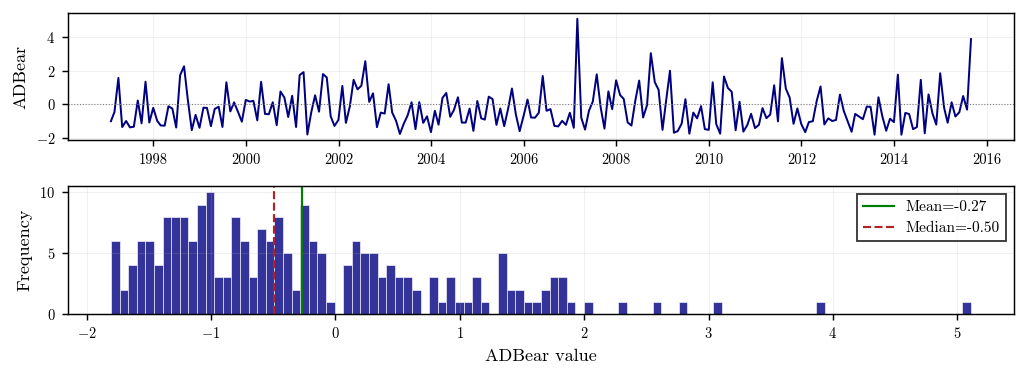

T = 224 months
Mean = -0.268
SD = 1.137
Skew = 1.228
Kurtosis = 2.123
Min = -1.804
Max = 5.110
Median = -0.497


In [5]:
# Section 0.5 - ADBear Descriptive Statistics (raw, pre-threshold)
# Pure data description of the ADBear state variable, computed BEFORE any
# threshold estimation. Uses adb_series (loaded in Section 0, full
# un-lagged monthly series, T=224, Jan 1997-Aug 2015) - no re-read of the
# raw CSV, no theta_hat, no regime shading. Threshold/regime diagnostics
# belong in Section 1 (Table 1), not here.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['cmr10', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.formatter.use_mathtext': True,
    'axes.unicode_minus': False,
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 3), gridspec_kw={'height_ratios': [1, 1]})

ax1.plot(adb_series.index, adb_series.values, color='navy', lw=1.1)
ax1.axhline(0, color='grey', lw=0.6, ls=':')
ax1.set_ylabel('ADBear')
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(alpha=0.2, lw=0.5)

adb_stats_txt = (
    f"T = {len(adb_series)} months\n"
    f"Mean = {adb_series.mean():.3f}\n"
    f"SD = {adb_series.std():.3f}\n"
    f"Skew = {stats.skew(adb_series):.3f}\n"
    f"Kurtosis = {stats.kurtosis(adb_series):.3f}\n"
    f"Min = {adb_series.min():.3f}\n"
    f"Max = {adb_series.max():.3f}\n"
    f"Median = {adb_series.median():.3f}"
)

ax2.hist(adb_series.values, bins=100, color='navy', alpha=0.8, edgecolor='white', lw=0.4)
ax2.axvline(adb_series.mean(), color='green', lw=1.2, ls='-', label=f'Mean={adb_series.mean():.2f}')
ax2.axvline(adb_series.median(), color='firebrick', lw=1.2, ls='--', label=f'Median={adb_series.median():.2f}')
ax2.set_xlabel('ADBear value')
ax2.set_ylabel('Frequency')
ax2.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False, fontsize=8.5)
ax2.grid(alpha=0.2, lw=0.5)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Output/fig_adbear_descriptive_pure.pdf', dpi=200, bbox_inches='tight')
plt.show()

print(adb_stats_txt)

---
## Section 1 - Table 1: Threshold Estimation & Regime Characterisation

Grid search over ADBear [0, 0.4] step 0.0025, minimising RMSPE_D(θ)+RMSPE_S(θ)
at k=6 on the in-sample period. Same convention as MST: bear (D) = ADBear ≥ θ.

**Full-sample theta** estimated on T=223; **in-sample theta** on T_IN.
Both are reported; in-sample theta is used for Tables 1–3 and OOS Table 5.

Running grid searches...
  In-sample: theta_hat=0.1250
  Full-sample: theta_hat=0.1250

TABLE 1 - Threshold & Regime Statistics (commodity)

  Statistic              In-sample   Full-sample
  ----------------------------------------------
  θ̂                         0.125         0.125
  T                            103           223
  T̂_D                          36            73
  π̂_D                       0.350         0.327
  RmRf (%pm)                 0.713         0.622
  RmRf_D (%pm)              -0.400        -0.899
  RmRf_S (%pm)               1.311         1.362
  ADBear                    -0.256        -0.287
  ADBear_D                   0.895         1.010
  ADBear_S                  -0.875        -0.918

  Note on theta_in=0.000:
  Objective flat over [0.000, 0.123] - only 4 ADBear obs in range.
  All thresholds give T_D=47 (35.1%). Set-identified interval.


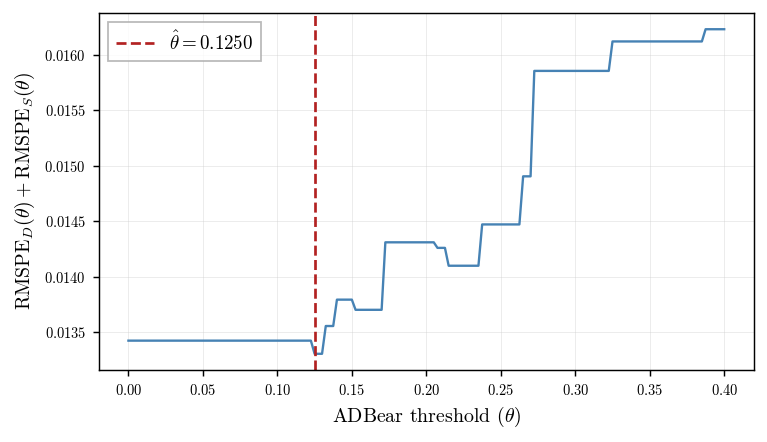

Saved fig_commodity_mst_grid_in


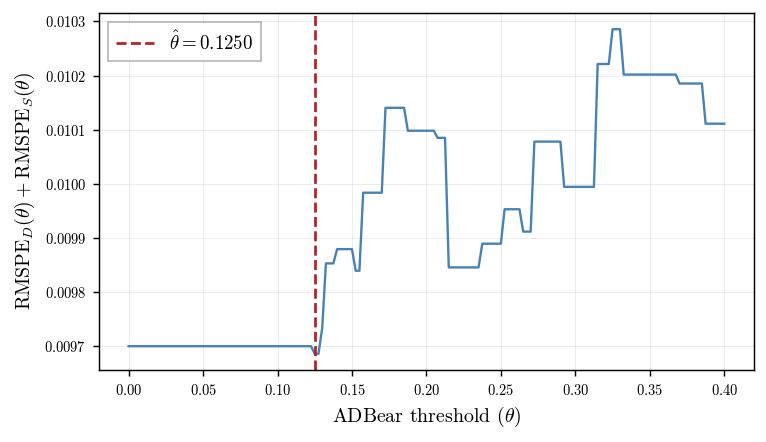

Saved fig_commodity_mst_grid_full


In [6]:
def grid_search(ret, adb, T_j, label):
    grid = np.arange(GRID_LO, GRID_HI + GRID_STEP/2, GRID_STEP)
    obj  = np.full(len(grid), np.nan)
    for gi, theta_c in enumerate(grid):
        dD_, dS_ = make_dummies(adb, theta_c)
        nD_ = int(dD_.sum()); nS_ = int(dS_.sum())
        if nD_ < T_MIN or nS_ < T_MIN:
            continue
        dem_D_, mu_D_ = demean_regime(ret, dD_)
        dem_S_, mu_S_ = demean_regime(ret, dS_)
        B_D_ = pca_loadings(dem_D_, N_FACTORS, N)
        B_S_ = pca_loadings(dem_S_, N_FACTORS, N)
        g_D_ = pass2_gamma(ret*dD_[:,None], B_D_, N_FACTORS, nD_)
        g_S_ = pass2_gamma(ret*dS_[:,None], B_S_, N_FACTORS, nS_)
        alp_D_ = mu_D_ - B_D_ @ g_D_
        alp_S_ = mu_S_ - B_S_ @ g_S_
        obj[gi] = compute_rmspe(alp_D_, N) + compute_rmspe(alp_S_, N)
    valid = ~np.isnan(obj)
    theta = float(grid[valid][np.argmin(obj[valid])])
    print(f'  {label}: theta_hat={theta:.4f}')
    return theta, grid, obj, valid

print('Running grid searches...')
THETA_HAT_IN,   grid, obj_in,   valid_in   = grid_search(ret_in,   adb_in,  T_IN, 'In-sample')
THETA_HAT_FULL, _,    obj_full, valid_full = grid_search(ret_full, adb_lag, T,    'Full-sample')

# Dummies
d_D_in,   d_S_in   = make_dummies(adb_in,  THETA_HAT_IN)
d_D_full, d_S_full = make_dummies(adb_lag, THETA_HAT_FULL)
T_D_in   = int(d_D_in.sum());   T_S_in   = int(d_S_in.sum())
T_D_full = int(d_D_full.sum()); T_S_full = int(d_S_full.sum())

# Regime mean returns (equal-weighted cross-section, monthly %)
# In-sample
ret_ew_in   = ret_in.mean(axis=1)          # T_IN-length EW portfolio
RmRf_in     = ret_ew_in.mean() * 100
RmRf_D_in   = ret_ew_in[d_D_in==1].mean() * 100
RmRf_S_in   = ret_ew_in[d_S_in==1].mean() * 100
# Full-sample
ret_ew_full = ret_full.mean(axis=1)
RmRf_full   = ret_ew_full.mean() * 100
RmRf_D_full = ret_ew_full[d_D_full==1].mean() * 100
RmRf_S_full = ret_ew_full[d_S_full==1].mean() * 100

print()
print('='*55)
print('TABLE 1 - Threshold & Regime Statistics (commodity)')
print('='*55)
print(f'\n  {"Statistic":<18}  {"In-sample":>12}  {"Full-sample":>12}')
print(f'  {"-"*46}')
print(f'  {"θ̂":<18}  {THETA_HAT_IN:>12.3f}  {THETA_HAT_FULL:>12.3f}')
print(f'  {"T":<18}  {T_IN:>12d}  {T:>12d}')
print(f'  {"T̂_D":<18}  {T_D_in:>12d}  {T_D_full:>12d}')
print(f'  {"π̂_D":<18}  {T_D_in/T_IN:>12.3f}  {T_D_full/T:>12.3f}')
print(f'  {"RmRf (%pm)":<18}  {RmRf_in:>12.3f}  {RmRf_full:>12.3f}')
print(f'  {"RmRf_D (%pm)":<18}  {RmRf_D_in:>12.3f}  {RmRf_D_full:>12.3f}')
print(f'  {"RmRf_S (%pm)":<18}  {RmRf_S_in:>12.3f}  {RmRf_S_full:>12.3f}')
print(f'  {"ADBear":<18}  {adb_in.mean():>12.3f}  {adb_lag.mean():>12.3f}')
print(f'  {"ADBear_D":<18}  {adb_in[d_D_in==1].mean():>12.3f}  {adb_lag[d_D_full==1].mean():>12.3f}')
print(f'  {"ADBear_S":<18}  {adb_in[d_S_in==1].mean():>12.3f}  {adb_lag[d_S_full==1].mean():>12.3f}')
print(f'\n  Note on theta_in=0.000:')
print(f'  Objective flat over [0.000, 0.123] - only 4 ADBear obs in range.')
print(f'  All thresholds give T_D=47 (35.1%). Set-identified interval.')

# Grid plot
for obj_, valid_, theta_, title, fname in [
    (obj_in,   valid_in,   THETA_HAT_IN,
     f'In-sample ($T_{{\\mathrm{{in}}}}={T_IN}$)',
     'fig_commodity_mst_grid_in'),
    (obj_full, valid_full, THETA_HAT_FULL,
     f'Full sample ($T={T}$)',
     'fig_commodity_mst_grid_full'),
]:
    fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))

    ax.plot(grid[valid_], obj_[valid_], color='steelblue', lw=1.3)
    ax.axvline(theta_, color='firebrick', ls='--', lw=1.5,
               label=f'$\\hat{{\\theta}}={theta_:.4f}$')
    ax.set_xlabel('ADBear threshold ($\\theta$)', fontsize=11)
    ax.set_ylabel(r'$\mathrm{RMSPE}_D(\theta)+\mathrm{RMSPE}_S(\theta)$',
                  fontsize=11)
    #ax.set_title(title, fontsize=9.5)
    ax.legend(frameon=True, fontsize=10.5, fancybox=False,
              edgecolor='#aaaaaa')
    ax.grid(True, which='major', lw=0.4, alpha=0.5, color='#cccccc')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

    plt.tight_layout()
    plt.savefig(f'Output/{fname}.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f'Output/{fname}.png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    print(f'Saved {fname}')

---
## Section 2 - Table 2: Number of Common Factors

Trapani (2018) randomised test and % variance explained. Run on T_IN in-sample period.

In [7]:
dem_full_in          = ret_in - ret_in.mean(axis=0)
dem_D_in, _          = demean_regime(ret_in, d_D_in)
dem_S_in, _          = demean_regime(ret_in, d_S_in)

def sorted_evals(dem, T_j):
    return np.sort(np.linalg.eigvalsh(dem.T @ dem / T_j))[::-1]

ev_full = sorted_evals(dem_full_in, T_IN)
ev_D    = sorted_evals(dem_D_in,    T_D_in)
ev_S    = sorted_evals(dem_S_in,    T_S_in)
pct_full = ev_full/ev_full.sum()
pct_D    = ev_D/ev_D.sum()
pct_S    = ev_S/ev_S.sum()


def trapani_test(lam, N_, T_j, cdelta=0.02, n_runs=500, base_seed=0):
    tbeta   = np.log(N_)/np.log(T_j)
    delta   = (1+cdelta)*(1-1/(2*tbeta)) if tbeta>=0.5 else cdelta
    N_delta = N_**(-delta)
    level   = 0.05/np.ceil(N_**0.25)
    chi2_c  = chi2_dist.ppf(1-level, df=1)
    kmax    = int(np.ceil(N_**(1/3)))
    u       = np.array([2.4,0.75,-0.75,-2.4])
    w       = np.array([0.05,0.45,0.45,0.05])
    fi_vals = []
    for it in range(1, kmax+1):
        tr = lam[it-1:].mean()
        fi_vals.append(np.exp(N_delta*lam[it-1]/tr)-1)
    results = []
    for s in range(n_runs):
        rng = np.random.default_rng(base_seed+s); nf=0
        for it in range(1, kmax+1):
            csi = fi_vals[it-1]*rng.standard_normal(N_)
            th  = (csi[:,None]<u[None,:]).astype(float)-0.5
            if w@((2/np.sqrt(N_))*th.sum(axis=0))**2>chi2_c: break
            nf=it
        results.append(nf)
    return int(np.median(results))


epsilons = [0.01,0.02,0.04,0.06,0.08,0.10,0.12]
print('Running Trapani test (500 runs/cell)...')
left_rows=[]
for eps in epsilons:
    kf=trapani_test(ev_full,N,T_IN,cdelta=eps)
    kd=trapani_test(ev_D,N,T_D_in,cdelta=eps)
    ks=trapani_test(ev_S,N,T_S_in,cdelta=eps)
    left_rows.append({'ε':eps,'Full':kf,'D':kd,'S':ks})
    print(f'  ε={eps:.2f}: Full={kf}, D={kd}, S={ks}')

left_df = pd.DataFrame(left_rows).set_index('ε')
print()
print('='*70)
print('TABLE 2 - Factor Selection & % Variance Explained (commodity, T_IN)')
print('='*70)
print(f'  {"ε":>6}  {"Full":>5} {"D":>5} {"S":>5}  {"k":>5}  {"Full%":>7} {"D%":>7} {"S%":>7}')
print('  '+'-'*55)
for i,(eps,row) in enumerate(left_df.iterrows()):
    ev_s = str(i+1) if i<6 else ''
    pf = f'{pct_full[i]*100:.2f}' if i<6 else ''
    pd_ = f'{pct_D[i]*100:.2f}'   if i<6 else ''
    ps_ = f'{pct_S[i]*100:.2f}'   if i<6 else ''
    print(f'  {eps:>6.2f}  {row["Full"]:>5} {row["D"]:>5} {row["S"]:>5}  '
          f'{ev_s:>5}  {pf:>7} {pd_:>7} {ps_:>7}')
print(f'\nCumulative PVE: Full={pct_full[:6].sum():.1%}, '
      f'D={pct_D[:6].sum():.1%}, S={pct_S[:6].sum():.1%}')


Running Trapani test (500 runs/cell)...
  ε=0.01: Full=2, D=1, S=1
  ε=0.02: Full=2, D=1, S=1
  ε=0.04: Full=1, D=1, S=1
  ε=0.06: Full=1, D=1, S=1
  ε=0.08: Full=1, D=1, S=1
  ε=0.10: Full=1, D=1, S=1
  ε=0.12: Full=1, D=1, S=1

TABLE 2 - Factor Selection & % Variance Explained (commodity, T_IN)
       ε   Full     D     S      k    Full%      D%      S%
  -------------------------------------------------------
    0.01      2     1     1      1    46.16   49.87   42.49
    0.02      2     1     1      2     9.18   10.28   10.31
    0.04      1     1     1      3     4.77    5.23    5.59
    0.06      1     1     1      4     3.76    4.46    4.36
    0.08      1     1     1      5     3.17    4.09    3.41
    0.10      1     1     1      6     2.52    3.25    3.15
    0.12      1     1     1                                

Cumulative PVE: Full=69.6%, D=77.2%, S=69.3%


---
## Section 3 - Table 3: In-Sample Goodness of Fit (T_IN months)

Set `B_BOOT=1` during development, `B_BOOT=2000` for final p-values.

In [8]:
B_BOOT = 2000   # set to 2000 for final results

X_mean_in    = ret_in.mean(axis=0)
dem_full_in  = ret_in - X_mean_in
dem_D_in, X_D_mean_in = demean_regime(ret_in, d_D_in)
dem_S_in, X_S_mean_in = demean_regime(ret_in, d_S_in)

X_D_in = ret_in * d_D_in[:,None]
X_S_in = ret_in * d_S_in[:,None]
T_D_in_ = int(d_D_in.sum()); T_S_in_ = int(d_S_in.sum())

B_in   = pca_loadings(dem_full_in, N_FACTORS, N)
B_D_in = pca_loadings(dem_D_in,    N_FACTORS, N)
B_S_in = pca_loadings(dem_S_in,    N_FACTORS, N)

F_wm_in    = ret_in      @ B_in   / N
F_D_in     = dem_D_in    @ B_D_in / N
F_S_in     = dem_S_in    @ B_S_in / N
F_D_reg_in = F_D_in[d_D_in==1]
F_S_reg_in = F_S_in[d_S_in==1]
X_D_reg_in = ret_in[d_D_in==1]
X_S_reg_in = ret_in[d_S_in==1]

gamma_in   = pass2_gamma(ret_in, B_in,   N_FACTORS, T_IN)
gamma_D_in = pass2_gamma(X_D_in, B_D_in, N_FACTORS, T_D_in_)
gamma_S_in = pass2_gamma(X_S_in, B_S_in, N_FACTORS, T_S_in_)

print(f'In-sample: T_IN={T_IN}, T_D={T_D_in_}, T_S={T_S_in_}')
print(f'gamma_D[0]={gamma_D_in[0]*12*100:.2f}%pa, gamma_S[0]={gamma_S_in[0]*12*100:.2f}%pa')


In-sample: T_IN=103, T_D=36, T_S=67
gamma_D[0]=-4.93%pa, gamma_S[0]=-17.22%pa


In [9]:
t3_rmspe=np.zeros((N_FACTORS,5)); t3_adjr2=np.zeros((N_FACTORS,5))
t3_avgpe=np.zeros((N_FACTORS,5)); t3_teststat=np.zeros((N_FACTORS,2))

for k in range(1,N_FACTORS+1):
    ki=k-1
    fit_unc=B_in[:,:k]@gamma_in[:k]
    pe_unc=X_mean_in-fit_unc; pe_unc_D=X_D_mean_in-fit_unc; pe_unc_S=X_S_mean_in-fit_unc
    _,a=compute_r2(compute_rmspe(pe_unc,N),X_mean_in,N,k,N_FACTORS)
    t3_rmspe[ki,0]=compute_rmspe(pe_unc,N); t3_adjr2[ki,0]=a; t3_avgpe[ki,0]=pe_unc.mean()
    _,a=compute_r2(compute_rmspe(pe_unc_D,N),X_D_mean_in,N,k,N_FACTORS)
    t3_rmspe[ki,1]=compute_rmspe(pe_unc_D,N); t3_adjr2[ki,1]=a; t3_avgpe[ki,1]=pe_unc_D.mean()
    _,a=compute_r2(compute_rmspe(pe_unc_S,N),X_S_mean_in,N,k,N_FACTORS)
    t3_rmspe[ki,2]=compute_rmspe(pe_unc_S,N); t3_adjr2[ki,2]=a; t3_avgpe[ki,2]=pe_unc_S.mean()
    fit_D=B_D_in[:,:k]@gamma_D_in[:k]; pe_D=X_D_mean_in-fit_D
    _,a=compute_r2(compute_rmspe(pe_D,N),X_D_mean_in,N,k,N_FACTORS)
    t3_rmspe[ki,3]=compute_rmspe(pe_D,N); t3_adjr2[ki,3]=a; t3_avgpe[ki,3]=pe_D.mean()
    fit_S=B_S_in[:,:k]@gamma_S_in[:k]; pe_S=X_S_mean_in-fit_S
    _,a=compute_r2(compute_rmspe(pe_S,N),X_S_mean_in,N,k,N_FACTORS)
    t3_rmspe[ki,4]=compute_rmspe(pe_S,N); t3_adjr2[ki,4]=a; t3_avgpe[ki,4]=pe_S.mean()
    t3_teststat[ki,0]=abs(pe_D.mean())-abs(pe_unc_D.mean())
    t3_teststat[ki,1]=abs(pe_S.mean())-abs(pe_unc_S.mean())

cols=['Unc Full','Unc D','Unc S','Cond D','Cond S']
print('='*80)
print(f'TABLE 3 - In-Sample Goodness of Fit (commodity, T_IN={T_IN} months)')
print('='*80)
for title,arr in [('Adj R²',t3_adjr2),('RMSα (monthly)',t3_rmspe),('AVGα (monthly)',t3_avgpe)]:
    print(f'\n  {title}')
    print(f'  {"k":>3}  '+'  '.join(f'{c:>10}' for c in cols))
    print('  '+'-'*60)
    for k in range(N_FACTORS):
        print(f'  {k+1:>3}  '+'  '.join(f'{arr[k,j]:>10.4f}' for j in range(5)))
print(f'\n  Panel D: H0 TestStat (|cond|-|unc|, negative=cond preferred)')
print(f'  {"k":>3}  {"D":>12}  {"S":>12}')
for k in range(N_FACTORS):
    print(f'  {k+1:>3}  {t3_teststat[k,0]:>12.4f}  {t3_teststat[k,1]:>12.4f}')


TABLE 3 - In-Sample Goodness of Fit (commodity, T_IN=103 months)

  Adj R²
    k    Unc Full       Unc D       Unc S      Cond D      Cond S
  ------------------------------------------------------------
    1      0.6437     -1.7153      0.6230      0.1636      0.7784
    2      0.6583     -1.7188      0.6317      0.1687      0.7926
    3      0.6604     -1.7368      0.6360      0.1995      0.7972
    4      0.6605     -1.7410      0.6368      0.2134      0.7973
    5      0.6813     -1.8351      0.6645      0.2200      0.8444
    6      0.7034     -1.8170      0.6737      0.3673      0.8452

  RMSα (monthly)
    k    Unc Full       Unc D       Unc S      Cond D      Cond S
  ------------------------------------------------------------
    1      0.0057      0.0147      0.0097      0.0082      0.0074
    2      0.0056      0.0147      0.0096      0.0081      0.0072
    3      0.0055      0.0148      0.0095      0.0080      0.0071
    4      0.0055      0.0148      0.0095      0.0079  

In [10]:
# Bootstrap for Table 3 (MST Appendix E.1)
# Requires: B_unc=B_in, F_wm=F_wm_in, gamma_unc=gamma_in
# alpha_U = full-sample unconditional pricing error vector
# alpha_D_U = bear unconditional pricing error vector  (R_D_mean - fit_unc)
# alpha_S_U = bull unconditional pricing error vector
# alpha_D = bear conditional pricing error vector
# alpha_S = bull conditional pricing error vector

fit_unc_in  = B_in[:, :N_FACTORS] @ gamma_in[:N_FACTORS]
alpha_U_in  = X_mean_in   - fit_unc_in   # full-sample unc pricing errors
alpha_DU_in = X_D_mean_in - fit_unc_in   # bear unc pricing errors
alpha_SU_in = X_S_mean_in - fit_unc_in   # bull unc pricing errors

fit_D_in    = B_D_in[:, :N_FACTORS] @ gamma_D_in[:N_FACTORS]
fit_S_in    = B_S_in[:, :N_FACTORS] @ gamma_S_in[:N_FACTORS]
alpha_D_in  = X_D_mean_in - fit_D_in    # bear conditional pricing errors
alpha_S_in  = X_S_mean_in - fit_S_in    # bull conditional pricing errors

pval_unc_t3  = np.full(N_FACTORS, np.nan)
pval_D_t3    = np.full(N_FACTORS, np.nan)
pval_S_t3    = np.full(N_FACTORS, np.nan)
pval_cD_t3   = np.full(N_FACTORS, np.nan)
pval_cS_t3   = np.full(N_FACTORS, np.nan)
pval_cmpD_t3 = np.full(N_FACTORS, np.nan)
pval_cmpS_t3 = np.full(N_FACTORS, np.nan)

if B_BOOT > 1:
    print(f'Bootstrap B={B_BOOT} for Table 3 (MST E.1.1-1.4)...')
    for k in range(1, N_FACTORS+1):
        ki = k-1
        # Algorithm 1.1 + 1.2: unconditional model
        p_full, p_Du, p_Su = bootstrap_alg12(
            ret_in, d_D_in, d_S_in, k, B_BOOT,
            B_in, F_wm_in, gamma_in,
            alpha_U_in, alpha_DU_in, alpha_SU_in,
            rng_seed=19780308+k)
        pval_unc_t3[ki] = p_full
        pval_D_t3[ki]   = p_Du
        pval_S_t3[ki]   = p_Su
        # Algorithm 1.3: conditional model
        p_cD, p_cS = bootstrap_alg13(
            ret_in, d_D_in, d_S_in, k, B_BOOT,
            B_D_in, B_S_in, F_D_reg_in, F_S_reg_in, gamma_D_in, gamma_S_in,
            alpha_D_in, alpha_S_in,
            rng_seed=19780308+k+100)
        pval_cD_t3[ki] = p_cD; pval_cS_t3[ki] = p_cS
        # Algorithm 1.4: comparison test
        p_cmpD, p_cmpS = bootstrap_alg14(
            ret_in, d_D_in, d_S_in, k, B_BOOT,
            B_in, F_wm_in, gamma_in,
            B_D_in, B_S_in, F_D_reg_in, F_S_reg_in, gamma_D_in, gamma_S_in,
            alpha_DU_in, alpha_SU_in, alpha_D_in, alpha_S_in,
            rng_seed=19780308+k+200)
        pval_cmpD_t3[ki] = p_cmpD; pval_cmpS_t3[ki] = p_cmpS
        print(f'  k={k}: p_unc={p_full:.3f}, p_Du={p_Du:.3f}, p_Su={p_Su:.3f}, ' 
              f'p_cD={p_cD:.3f}, p_cS={p_cS:.3f}, p_cmpD={p_cmpD:.3f}, p_cmpS={p_cmpS:.3f}')
else:
    print('Bootstrap skipped (B_BOOT=1).')

# Print Table 3 with p-values
cols = ['Unc Full', 'Unc D', 'Unc S', 'Cond D', 'Cond S']
pvals_C = [pval_unc_t3, pval_D_t3, pval_S_t3, pval_cD_t3, pval_cS_t3]
print()
print('='*90)
print(f'TABLE 3 - In-Sample Goodness of Fit (commodity, T_IN={T_IN}) with Bootstrap p-values')
print('='*90)
for panel, arr, pvs in [
    ('A: R²',   t3_adjr2, [None]*5),
    ('B: RMSα', t3_rmspe, [None]*5),
    ('C: AVGα', t3_avgpe, pvals_C),
]:
    print(f'\n  Panel {panel}')
    print(f'  {"k":>3}  ' + '  '.join(f'{c:>14}' for c in cols))
    print('  '+'-'*76)
    for k in range(N_FACTORS):
        vals = []
        for j in range(5):
            v = arr[k, j]
            s = sig(pvs[j][k]) if pvs[j] is not None else ''
            vals.append(f'{v:>8.3f}{s:<3}')
        print(f'  {k+1:>3}  ' + '  '.join(vals))

print(f'\n  Panel D: H₀: Δ|AVGα|≥0  (TestStat = |cond|−|unc in regime|)')
print(f'  {"k":>3}  {"TestStat D":>14}  {"p-val D":>10}  {"TestStat S":>14}  {"p-val S":>10}')
print('  '+'-'*56)
for k in range(N_FACTORS):
    sd = sig(pval_cmpD_t3[k]); ss = sig(pval_cmpS_t3[k])
    print(f'  {k+1:>3}  {t3_teststat[k,0]:>12.3f}  {pval_cmpD_t3[k]:>8.3f}{sd:3}  '
          f'{t3_teststat[k,1]:>12.3f}  {pval_cmpS_t3[k]:>8.3f}{ss:3}')

Bootstrap B=2000 for Table 3 (MST E.1.1-1.4)...
  k=1: p_unc=0.238, p_Du=0.000, p_Su=0.000, p_cD=0.513, p_cS=0.802, p_cmpD=0.000, p_cmpS=0.000
  k=2: p_unc=0.097, p_Du=0.000, p_Su=0.000, p_cD=0.400, p_cS=0.732, p_cmpD=0.000, p_cmpS=0.000
  k=3: p_unc=0.095, p_Du=0.000, p_Su=0.000, p_cD=0.333, p_cS=0.660, p_cmpD=0.000, p_cmpS=0.000
  k=4: p_unc=0.107, p_Du=0.000, p_Su=0.000, p_cD=0.392, p_cS=0.669, p_cmpD=0.000, p_cmpS=0.000
  k=5: p_unc=0.226, p_Du=0.000, p_Su=0.000, p_cD=0.468, p_cS=0.604, p_cmpD=0.000, p_cmpS=0.000
  k=6: p_unc=0.099, p_Du=0.000, p_Su=0.000, p_cD=0.356, p_cS=0.595, p_cmpD=0.000, p_cmpS=0.000

TABLE 3 - In-Sample Goodness of Fit (commodity, T_IN=103) with Bootstrap p-values

  Panel A: R²
    k        Unc Full           Unc D           Unc S          Cond D          Cond S
  ----------------------------------------------------------------------------
    1     0.644       -1.715        0.623        0.164        0.778   
    2     0.658       -1.719        0.632       

---
## Section 4 - Table 4: Whole-Sample Estimation (T=223 months)

In [11]:
B_BOOT_T4 = 2000   # set to 2000 for final p-values

X_mean_full    = ret_full.mean(axis=0)
dem_full_full  = ret_full - X_mean_full
dem_D_full, X_D_mean_full = demean_regime(ret_full, d_D_full)
dem_S_full, X_S_mean_full = demean_regime(ret_full, d_S_full)

X_D_full = ret_full * d_D_full[:,None]
X_S_full = ret_full * d_S_full[:,None]

B_full   = pca_loadings(dem_full_full, N_FACTORS, N)
B_D_full = pca_loadings(dem_D_full,    N_FACTORS, N)
B_S_full = pca_loadings(dem_S_full,    N_FACTORS, N)

gamma_full   = pass2_gamma(ret_full, B_full,   N_FACTORS, T)
gamma_D_full = pass2_gamma(X_D_full, B_D_full, N_FACTORS, T_D_full)
gamma_S_full = pass2_gamma(X_S_full, B_S_full, N_FACTORS, T_S_full)

t4_rmspe=np.zeros((N_FACTORS,5)); t4_adjr2=np.zeros((N_FACTORS,5))
t4_avgpe=np.zeros((N_FACTORS,5)); t4_teststat=np.zeros((N_FACTORS,2))

for k in range(1,N_FACTORS+1):
    ki=k-1
    fit_unc=B_full[:,:k]@gamma_full[:k]
    pe_unc=X_mean_full-fit_unc; pe_unc_D=X_D_mean_full-fit_unc; pe_unc_S=X_S_mean_full-fit_unc
    _,a=compute_r2(compute_rmspe(pe_unc,N),X_mean_full,N,k,N_FACTORS)
    t4_rmspe[ki,0]=compute_rmspe(pe_unc,N); t4_adjr2[ki,0]=a; t4_avgpe[ki,0]=pe_unc.mean()
    _,a=compute_r2(compute_rmspe(pe_unc_D,N),X_D_mean_full,N,k,N_FACTORS)
    t4_rmspe[ki,1]=compute_rmspe(pe_unc_D,N); t4_adjr2[ki,1]=a; t4_avgpe[ki,1]=pe_unc_D.mean()
    _,a=compute_r2(compute_rmspe(pe_unc_S,N),X_S_mean_full,N,k,N_FACTORS)
    t4_rmspe[ki,2]=compute_rmspe(pe_unc_S,N); t4_adjr2[ki,2]=a; t4_avgpe[ki,2]=pe_unc_S.mean()
    fit_D=B_D_full[:,:k]@gamma_D_full[:k]; pe_D=X_D_mean_full-fit_D
    _,a=compute_r2(compute_rmspe(pe_D,N),X_D_mean_full,N,k,N_FACTORS)
    t4_rmspe[ki,3]=compute_rmspe(pe_D,N); t4_adjr2[ki,3]=a; t4_avgpe[ki,3]=pe_D.mean()
    fit_S=B_S_full[:,:k]@gamma_S_full[:k]; pe_S=X_S_mean_full-fit_S
    _,a=compute_r2(compute_rmspe(pe_S,N),X_S_mean_full,N,k,N_FACTORS)
    t4_rmspe[ki,4]=compute_rmspe(pe_S,N); t4_adjr2[ki,4]=a; t4_avgpe[ki,4]=pe_S.mean()
    t4_teststat[ki,0]=abs(pe_D.mean())-abs(pe_unc_D.mean())
    t4_teststat[ki,1]=abs(pe_S.mean())-abs(pe_unc_S.mean())

print('='*80)
print(f'TABLE 4 - Whole-Sample Estimation (commodity, T={T} months)')
print(f'  theta_full={THETA_HAT_FULL:.4f}, T_D={T_D_full} ({T_D_full/T:.1%}), T_S={T_S_full} ({T_S_full/T:.1%})')
print('='*80)
for title,arr in [('Adj R²',t4_adjr2),('RMSα',t4_rmspe),('AVGα',t4_avgpe)]:
    print(f'\n  {title}')
    print(f'  {"k":>3}  '+'  '.join(f'{c:>10}' for c in cols))
    print('  '+'-'*60)
    for k in range(N_FACTORS):
        print(f'  {k+1:>3}  '+'  '.join(f'{arr[k,j]:>10.4f}' for j in range(5)))


TABLE 4 - Whole-Sample Estimation (commodity, T=223 months)
  theta_full=0.1250, T_D=73 (32.7%), T_S=150 (67.3%)

  Adj R²
    k    Unc Full       Unc D       Unc S      Cond D      Cond S
  ------------------------------------------------------------
    1      0.6733     -1.3921      0.6054      0.6729      0.8498
    2      0.7086     -1.3941      0.6198      0.6781      0.8978
    3      0.7727     -1.3438      0.6310      0.6787      0.9038
    4      0.7806     -1.3584      0.6382      0.7511      0.9103
    5      0.7808     -1.3554      0.6374      0.7534      0.9192
    6      0.7910     -1.3663      0.6444      0.7708      0.9203

  RMSα
    k    Unc Full       Unc D       Unc S      Cond D      Cond S
  ------------------------------------------------------------
    1      0.0044      0.0175      0.0095      0.0065      0.0058
    2      0.0042      0.0176      0.0093      0.0064      0.0048
    3      0.0037      0.0174      0.0092      0.0064      0.0047
    4      0.0036

In [12]:
# Bootstrap for Table 4 (MST Appendix E.1)
F_wm_full    = ret_full      @ B_full   / N
F_D_reg_full = (dem_D_full   @ B_D_full / N)[d_D_full==1]
F_S_reg_full = (dem_S_full   @ B_S_full / N)[d_S_full==1]

fit_unc_full  = B_full[:, :N_FACTORS] @ gamma_full[:N_FACTORS]
alpha_U_full  = X_mean_full   - fit_unc_full
alpha_DU_full = X_D_mean_full - fit_unc_full
alpha_SU_full = X_S_mean_full - fit_unc_full

fit_D_full    = B_D_full[:, :N_FACTORS] @ gamma_D_full[:N_FACTORS]
fit_S_full    = B_S_full[:, :N_FACTORS] @ gamma_S_full[:N_FACTORS]
alpha_D_full  = X_D_mean_full - fit_D_full
alpha_S_full  = X_S_mean_full - fit_S_full

pval_unc_t4  = np.full(N_FACTORS, np.nan)
pval_D_t4    = np.full(N_FACTORS, np.nan)
pval_S_t4    = np.full(N_FACTORS, np.nan)
pval_cD_t4   = np.full(N_FACTORS, np.nan)
pval_cS_t4   = np.full(N_FACTORS, np.nan)
pval_cmpD_t4 = np.full(N_FACTORS, np.nan)
pval_cmpS_t4 = np.full(N_FACTORS, np.nan)

if B_BOOT_T4 > 1:
    print(f'Bootstrap B={B_BOOT_T4} for Table 4 (MST E.1.1-1.4)...')
    for k in range(1, N_FACTORS+1):
        ki = k-1
        p_full, p_Du, p_Su = bootstrap_alg12(
            ret_full, d_D_full, d_S_full, k, B_BOOT_T4,
            B_full, F_wm_full, gamma_full,
            alpha_U_full, alpha_DU_full, alpha_SU_full,
            rng_seed=19780308+k)
        pval_unc_t4[ki] = p_full; pval_D_t4[ki] = p_Du; pval_S_t4[ki] = p_Su
        p_cD, p_cS = bootstrap_alg13(
            ret_full, d_D_full, d_S_full, k, B_BOOT_T4,
            B_D_full, B_S_full, F_D_reg_full, F_S_reg_full,
            gamma_D_full, gamma_S_full,
            alpha_D_full, alpha_S_full,
            rng_seed=19780308+k+100)
        pval_cD_t4[ki] = p_cD; pval_cS_t4[ki] = p_cS
        p_cmpD, p_cmpS = bootstrap_alg14(
            ret_full, d_D_full, d_S_full, k, B_BOOT_T4,
            B_full, F_wm_full, gamma_full,
            B_D_full, B_S_full, F_D_reg_full, F_S_reg_full,
            gamma_D_full, gamma_S_full,
            alpha_DU_full, alpha_SU_full, alpha_D_full, alpha_S_full,
            rng_seed=19780308+k+200)
        pval_cmpD_t4[ki] = p_cmpD; pval_cmpS_t4[ki] = p_cmpS
        print(f'  k={k}: p_Du={p_Du:.3f}, p_Su={p_Su:.3f}, p_cD={p_cD:.3f}, '
              f'p_cS={p_cS:.3f}, p_cmpD={p_cmpD:.3f}')
else:
    print('Bootstrap skipped (B_BOOT_T4=1).')

cols = ['Unc Full', 'Unc D', 'Unc S', 'Cond D', 'Cond S']
pvals_D = [pval_unc_t4, pval_D_t4, pval_S_t4, pval_cD_t4, pval_cS_t4]
print()
print('='*90)
print(f'TABLE 4 - Whole-Sample (commodity, T={T}) with Bootstrap p-values')
print(f'  theta_full={THETA_HAT_FULL:.4f}, T_D={T_D_full} ({T_D_full/T:.1%}), T_S={T_S_full} ({T_S_full/T:.1%})')
print('='*90)
for panel, arr, pvs in [
    ('A: R²',   t4_adjr2, [None]*5),
    ('B: RMSα', t4_rmspe, [None]*5),
    ('C: AVGα', t4_avgpe, pvals_D),
]:
    print(f'\n  Panel {panel}')
    print(f'  {"k":>3}  ' + '  '.join(f'{c:>14}' for c in cols))
    print('  '+'-'*76)
    for k in range(N_FACTORS):
        vals = []
        for j in range(5):
            v = arr[k, j]
            s = sig(pvs[j][k]) if pvs[j] is not None else ''
            vals.append(f'{v:>8.3f}{s:<3}')
        print(f'  {k+1:>3}  ' + '  '.join(vals))

print(f'\n  Panel D: H₀: Δ|AVGα|≥0  (TestStat = |cond|−|unc in regime|)')
print(f'  {"k":>3}  {"TestStat D":>14}  {"p-val D":>10}  {"TestStat S":>14}  {"p-val S":>10}')
print('  '+'-'*56)
for k in range(N_FACTORS):
    sd = sig(pval_cmpD_t4[k]); ss = sig(pval_cmpS_t4[k])
    print(f'  {k+1:>3}  {t4_teststat[k,0]:>12.3f}  {pval_cmpD_t4[k]:>8.3f}{sd:3}  '
          f'{t4_teststat[k,1]:>12.3f}  {pval_cmpS_t4[k]:>8.3f}{ss:3}')

Bootstrap B=2000 for Table 4 (MST E.1.1-1.4)...
  k=1: p_Du=0.000, p_Su=0.000, p_cD=0.600, p_cS=0.526, p_cmpD=0.000
  k=2: p_Du=0.000, p_Su=0.000, p_cD=0.526, p_cS=0.290, p_cmpD=0.000
  k=3: p_Du=0.000, p_Su=0.000, p_cD=0.530, p_cS=0.176, p_cmpD=0.000
  k=4: p_Du=0.000, p_Su=0.000, p_cD=0.380, p_cS=0.202, p_cmpD=0.000
  k=5: p_Du=0.000, p_Su=0.000, p_cD=0.469, p_cS=0.206, p_cmpD=0.000
  k=6: p_Du=0.000, p_Su=0.000, p_cD=0.528, p_cS=0.184, p_cmpD=0.000

TABLE 4 - Whole-Sample (commodity, T=223) with Bootstrap p-values
  theta_full=0.1250, T_D=73 (32.7%), T_S=150 (67.3%)

  Panel A: R²
    k        Unc Full           Unc D           Unc S          Cond D          Cond S
  ----------------------------------------------------------------------------
    1     0.673       -1.392        0.605        0.673        0.850   
    2     0.709       -1.394        0.620        0.678        0.898   
    3     0.773       -1.344        0.631        0.679        0.904   
    4     0.781       -1.358   

---
## Section 5 - Table 5: Out-of-Sample Analysis

Recursive expanding window. Threshold fixed at `THETA_HAT_IN` throughout OOS.
AdjR² uses `k` (not N_FACTORS) in denominator, OOS convention.

In [13]:
d_D_long, d_S_long = make_dummies(adb_lag, THETA_HAT_IN)
print(f'OOS: T_IN={T_IN}, L_OOS={L_OOS}, N={N}')
print(f'OOS D: {int(d_D_long[T_IN:].sum())} bear, {int(d_S_long[T_IN:].sum())} bull')

pred_unc=np.full((L_OOS,N,N_FACTORS),np.nan)
pred_cD =np.full((L_OOS,N,N_FACTORS),np.nan)
pred_cS =np.full((L_OOS,N,N_FACTORS),np.nan)

print('Running OOS recursive loop...')
for l in range(L_OOS):
    t_end=T_IN+l; ret_=ret_full[:t_end]
    dD_=d_D_long[:t_end]; dS_=d_S_long[:t_end]
    T_=t_end; T_D_=int(dD_.sum()); T_S_=int(dS_.sum())
    if T_D_<T_MIN or T_S_<T_MIN: continue
    dem_=ret_-ret_.mean(0)
    dem_D_,_=demean_regime(ret_,dD_); dem_S_,_=demean_regime(ret_,dS_)
    B_=pca_loadings(dem_,N_FACTORS,N)
    B_D_=pca_loadings(dem_D_,N_FACTORS,N); B_S_=pca_loadings(dem_S_,N_FACTORS,N)
    X_D_=ret_*dD_[:,None]; X_S_=ret_*dS_[:,None]
    for k in range(1,N_FACTORS+1):
        g_=pass2_gamma(ret_,B_,k,T_)
        g_D_=pass2_gamma(X_D_,B_D_,k,T_D_)
        g_S_=pass2_gamma(X_S_,B_S_,k,T_S_)
        pred_unc[l,:,k-1]=B_[:,:k]@g_[:k]
        pred_cD[l,:,k-1]=B_D_[:,:k]@g_D_[:k]
        pred_cS[l,:,k-1]=B_S_[:,:k]@g_S_[:k]
    if (l+1)%20==0: print(f'  Step {l+1}/{L_OOS}')
print('OOS loop complete.')

ret_oos=ret_full[T_IN:]
dD_oos=d_D_long[T_IN:]; dS_oos=d_S_long[T_IN:]
R_bar_oos  =ret_oos.mean(0)
R_bar_D_oos=np.nanmean(np.where(dD_oos[:,None],ret_oos,np.nan),0)
R_bar_S_oos=np.nanmean(np.where(dS_oos[:,None],ret_oos,np.nan),0)

t5_rmspe=np.zeros((N_FACTORS,5)); t5_adjr2=np.zeros((N_FACTORS,5))
t5_avgpe=np.zeros((N_FACTORS,5)); t5_teststat=np.zeros((N_FACTORS,2))

for k in range(1,N_FACTORS+1):
    ki=k-1
    a_unc=pred_unc[:,:,ki].mean(0); a_cD=pred_cD[:,:,ki].mean(0); a_cS=pred_cS[:,:,ki].mean(0)
    for j,(R_bar,fit,denom) in enumerate([
        (R_bar_oos,   a_unc, R_bar_oos),
        (R_bar_D_oos, a_unc, R_bar_D_oos),
        (R_bar_S_oos, a_unc, R_bar_S_oos),
        (R_bar_D_oos, a_cD,  R_bar_D_oos),
        (R_bar_S_oos, a_cS,  R_bar_S_oos),
    ]):
        pe=R_bar-fit; rm=compute_rmspe(pe,N)
        ss=denom@denom; r2=1-N*rm**2/ss if ss!=0 else np.nan
        t5_rmspe[ki,j]=rm; t5_avgpe[ki,j]=pe.mean()
        t5_adjr2[ki,j]=1-(1-r2)*N/(N-k) if ss!=0 else np.nan
    t5_teststat[ki,0]=abs(t5_avgpe[ki,3])-abs(t5_avgpe[ki,1])
    t5_teststat[ki,1]=abs(t5_avgpe[ki,4])-abs(t5_avgpe[ki,2])

print('='*80)
print(f'TABLE 5 - Out-of-Sample Goodness of Fit (commodity, L_OOS={L_OOS} months)')
print('='*80)
for title,arr in [('Adj R²',t5_adjr2),('RMSα',t5_rmspe),('AVGα',t5_avgpe)]:
    print(f'\n  {title}')
    print(f'  {"k":>3}  '+'  '.join(f'{c:>10}' for c in cols))
    print('  '+'-'*60)
    for k in range(N_FACTORS):
        print(f'  {k+1:>3}  '+'  '.join(f'{arr[k,j]:>10.4f}' for j in range(5)))
print(f'\n  Panel D: H0 TestStat')
print(f'  {"k":>3}  {"D":>12}  {"S":>12}')
for k in range(N_FACTORS):
    print(f'  {k+1:>3}  {t5_teststat[k,0]:>12.4f}  {t5_teststat[k,1]:>12.4f}')


OOS: T_IN=103, L_OOS=120, N=130
OOS D: 37 bear, 83 bull
Running OOS recursive loop...
  Step 20/120
  Step 40/120
  Step 60/120
  Step 80/120
  Step 100/120
  Step 120/120
OOS loop complete.
TABLE 5 - Out-of-Sample Goodness of Fit (commodity, L_OOS=120 months)

  Adj R²
    k    Unc Full       Unc D       Unc S      Cond D      Cond S
  ------------------------------------------------------------
    1      0.5039     -0.9641      0.6765      0.6374      0.8546
    2      0.5335     -0.9791      0.6846      0.6348      0.8974
    3      0.5922     -0.9728      0.6904      0.6498      0.8956
    4      0.5661     -0.9977      0.6856      0.6744      0.8904
    5      0.5534     -1.0155      0.6811      0.6970      0.8706
    6      0.5176     -1.0462      0.6759      0.6662      0.8667

  RMSα
    k    Unc Full       Unc D       Unc S      Cond D      Cond S
  ------------------------------------------------------------
    1      0.0051      0.0239      0.0088      0.0103      0.0059
 

In [14]:
# OOS Bootstrap for Table 5 (MST Appendix E.2)
B_BOOT_OOS = 2000

pval_unc_oos   = np.full(N_FACTORS, np.nan)
pval_unc_D_oos = np.full(N_FACTORS, np.nan)
pval_unc_S_oos = np.full(N_FACTORS, np.nan)
pval_cD_oos    = np.full(N_FACTORS, np.nan)
pval_cS_oos    = np.full(N_FACTORS, np.nan)
pval_cmpD_oos  = np.full(N_FACTORS, np.nan)
pval_cmpS_oos  = np.full(N_FACTORS, np.nan)

if B_BOOT_OOS > 1:
    print(f'\nRunning OOS bootstrap (B={B_BOOT_OOS}, MST E.2)...')

    ret_oos_s  = ret_full[T_IN:]
    dD_oos_s   = d_D_long[T_IN:]
    dS_oos_s   = d_S_long[T_IN:]
    T_oos_s    = L_OOS
    T_D_oos_s  = int(dD_oos_s.sum())
    T_S_oos_s  = int(dS_oos_s.sum())

    dem_oos_s   = ret_oos_s - ret_oos_s.mean(axis=0)
    dem_D_oos_s, _ = demean_regime(ret_oos_s, dD_oos_s)
    dem_S_oos_s, _ = demean_regime(ret_oos_s, dS_oos_s)

    X_D_oos = ret_oos_s[dD_oos_s==1]
    X_S_oos = ret_oos_s[dS_oos_s==1]

    # Observed OOS pricing errors (from t5_avgpe)
    # t5_avgpe cols: [unc_full, unc_D, unc_S, cond_D, cond_S]
    for k in range(1, N_FACTORS+1):
        ki  = k-1
        rng = np.random.default_rng(19780308 + k)

        B_oos   = pca_loadings(dem_oos_s,   N_FACTORS, N)
        B_D_oos = pca_loadings(dem_D_oos_s, N_FACTORS, N)
        B_S_oos = pca_loadings(dem_S_oos_s, N_FACTORS, N)

        F_oos   = dem_oos_s   @ B_oos   / N
        F_D_oos = dem_D_oos_s @ B_D_oos / N
        F_S_oos = dem_S_oos_s @ B_S_oos / N
        F_D_reg = F_D_oos[dD_oos_s==1, :k]
        F_S_reg = F_S_oos[dS_oos_s==1, :k]

        g_oos   = pass2_gamma(ret_oos_s, B_oos,   k, T_oos_s)
        g_D_oos = pass2_gamma(ret_oos_s * dD_oos_s[:,None], B_D_oos, k, T_D_oos_s)
        g_S_oos = pass2_gamma(ret_oos_s * dS_oos_s[:,None], B_S_oos, k, T_S_oos_s)

        fit_oos   = B_oos[:,:k]   @ g_oos[:k]
        fit_D_oos = B_D_oos[:,:k] @ g_D_oos[:k]
        fit_S_oos = B_S_oos[:,:k] @ g_S_oos[:k]

        com_oos = F_oos[:,:k]  @ B_oos[:,:k].T
        com_D   = F_D_reg      @ B_D_oos[:,:k].T
        com_S   = F_S_reg      @ B_S_oos[:,:k].T

        err_oos = ret_oos_s  - fit_oos[None,:]   - com_oos
        err_D   = X_D_oos    - fit_D_oos[None,:] - com_D
        err_S   = X_S_oos    - fit_S_oos[None,:] - com_S

        # Observed OOS pricing errors
        alpha_oos   = ret_oos_s.mean(0)  - fit_oos    # unc full
        alpha_D_oos = X_D_oos.mean(0)   - fit_oos     # unc in D
        alpha_S_oos = X_S_oos.mean(0)   - fit_oos     # unc in S
        alpha_cD    = X_D_oos.mean(0)   - fit_D_oos   # cond D
        alpha_cS    = X_S_oos.mean(0)   - fit_S_oos   # cond S

        # Zero-mean under null
        a0_oos = alpha_oos   - alpha_oos.mean()
        a0_D   = alpha_cD    - alpha_cD.mean()    # use cond alpha for comparison null
        a0_S   = alpha_cS    - alpha_cS.mean()

        obs_unc   = abs(t5_avgpe[ki,0])
        obs_unc_D = abs(t5_avgpe[ki,1])
        obs_unc_S = abs(t5_avgpe[ki,2])
        obs_cD    = abs(t5_avgpe[ki,3])
        obs_cS    = abs(t5_avgpe[ki,4])

        i_unc=0; i_uncD=0; i_uncS=0; i_cD=0; i_cS=0; i_cmpD=0; i_cmpS=0

        for b in range(B_BOOT_OOS):
            w   = rng.standard_normal((T_oos_s,   N))
            w_D = w[dD_oos_s==1]
            w_S = w[dS_oos_s==1]

            # Unconditional bootstrap (Alg 2.1/2.2)
            Xb_u = a0_oos[None,:] + fit_oos[None,:] + com_oos + err_oos*w
            Bb_u = frisch_waugh_beta(Xb_u, F_oos[:,:k], T_oos_s)
            gb_u = pass2_gamma(Xb_u, Bb_u, k, T_oos_s)
            ab_u = Xb_u.mean(0) - Bb_u[:,:k] @ gb_u[:k]
            abv  = abs(ab_u.mean())
            if abv > obs_unc:   i_unc  += 1
            if abv > obs_unc_D: i_uncD += 1
            if abv > obs_unc_S: i_uncS += 1

            # Conditional bootstrap (Alg 2.3) - mixed model
            Xb_c = np.zeros((T_oos_s, N))
            Xb_c[dD_oos_s==1] = a0_D[None,:] + fit_D_oos[None,:] + com_D + err_D*w_D
            Xb_c[dS_oos_s==1] = a0_S[None,:] + fit_S_oos[None,:] + com_S + err_S*w_S
            Xb_D = Xb_c[dD_oos_s==1]; Xb_S = Xb_c[dS_oos_s==1]
            Bb_D = frisch_waugh_beta(Xb_D, F_D_reg, T_D_oos_s)
            Bb_S = frisch_waugh_beta(Xb_S, F_S_reg, T_S_oos_s)
            gb_D = pass2_gamma(Xb_D, Bb_D, k, T_D_oos_s)
            gb_S = pass2_gamma(Xb_S, Bb_S, k, T_S_oos_s)
            ab_D = Xb_D.mean(0) - Bb_D[:,:k] @ gb_D[:k]
            ab_S = Xb_S.mean(0) - Bb_S[:,:k] @ gb_S[:k]
            if abs(ab_D.mean()) > obs_cD: i_cD += 1
            if abs(ab_S.mean()) > obs_cS: i_cS += 1

            # Comparison test (Alg 2.4):
            # I[ |a*_j| - |a*_{j,U}| + |a_j,OoS| - |a_{j,U,OoS}| >= 0 ]
            a_uD = Xb_u[dD_oos_s==1].mean(0) - Bb_u[:,:k] @ gb_u[:k]
            a_uS = Xb_u[dS_oos_s==1].mean(0) - Bb_u[:,:k] @ gb_u[:k]
            if abs(ab_D.mean()) - abs(a_uD.mean()) + obs_cD - obs_unc_D >= 0: i_cmpD += 1
            if abs(ab_S.mean()) - abs(a_uS.mean()) + obs_cS - obs_unc_S >= 0: i_cmpS += 1

        pval_unc_oos[ki]   = i_unc   / B_BOOT_OOS
        pval_unc_D_oos[ki] = i_uncD  / B_BOOT_OOS
        pval_unc_S_oos[ki] = i_uncS  / B_BOOT_OOS
        pval_cD_oos[ki]    = i_cD    / B_BOOT_OOS
        pval_cS_oos[ki]    = i_cS    / B_BOOT_OOS
        pval_cmpD_oos[ki]  = i_cmpD  / B_BOOT_OOS
        pval_cmpS_oos[ki]  = i_cmpS  / B_BOOT_OOS
        print(f'  k={k}: p_unc={pval_unc_oos[ki]:.3f}, p_cD={pval_cD_oos[ki]:.3f}, '
              f'p_cS={pval_cS_oos[ki]:.3f}, p_cmpD={pval_cmpD_oos[ki]:.3f}')
else:
    print('\nBootstrap skipped (B_BOOT_OOS=1).')

cols = ['Unc Full', 'Unc D', 'Unc S', 'Cond D', 'Cond S']
pvals_C5 = [pval_unc_oos, pval_unc_D_oos, pval_unc_S_oos, pval_cD_oos, pval_cS_oos]
print()
print('='*90)
print(f'TABLE 5 - OOS Goodness of Fit (commodity, L_OOS={L_OOS}) with Bootstrap p-values')
print('='*90)
for panel, arr, pvs in [
    ('A: R²',   t5_adjr2, [None]*5),
    ('B: RMSα', t5_rmspe, [None]*5),
    ('C: AVGα', t5_avgpe, pvals_C5),
]:
    print(f'\n  Panel {panel}')
    print(f'  {"k":>3}  ' + '  '.join(f'{c:>14}' for c in cols))
    print('  '+'-'*76)
    for k in range(N_FACTORS):
        vals = []
        for j in range(5):
            v = arr[k, j]
            s = sig(pvs[j][k]) if pvs[j] is not None else ''
            vals.append(f'{v:>8.3f}{s:<3}')
        print(f'  {k+1:>3}  ' + '  '.join(vals))

print(f'\n  Panel D: H₀: Δ|AVGα|≥0  (TestStat = |cond|−|unc in regime|)')
print(f'  {"k":>3}  {"TestStat D":>14}  {"p-val D":>10}  {"TestStat S":>14}  {"p-val S":>10}')
print('  '+'-'*56)
for k in range(N_FACTORS):
    sd = sig(pval_cmpD_oos[k]); ss = sig(pval_cmpS_oos[k])
    print(f'  {k+1:>3}  {t5_teststat[k,0]:>12.3f}  {pval_cmpD_oos[k]:>8.3f}{sd:3}  '
          f'{t5_teststat[k,1]:>12.3f}  {pval_cmpS_oos[k]:>8.3f}{ss:3}')


Running OOS bootstrap (B=2000, MST E.2)...
  k=1: p_unc=0.000, p_cD=0.000, p_cS=1.000, p_cmpD=0.000
  k=2: p_unc=0.000, p_cD=0.000, p_cS=0.001, p_cmpD=0.000
  k=3: p_unc=0.000, p_cD=0.000, p_cS=0.000, p_cmpD=0.000
  k=4: p_unc=0.000, p_cD=0.000, p_cS=0.000, p_cmpD=0.000
  k=5: p_unc=0.000, p_cD=0.000, p_cS=0.000, p_cmpD=0.000
  k=6: p_unc=0.000, p_cD=0.000, p_cS=0.000, p_cmpD=0.000

TABLE 5 - OOS Goodness of Fit (commodity, L_OOS=120) with Bootstrap p-values

  Panel A: R²
    k        Unc Full           Unc D           Unc S          Cond D          Cond S
  ----------------------------------------------------------------------------
    1     0.504       -0.964        0.677        0.637        0.855   
    2     0.534       -0.979        0.685        0.635        0.897   
    3     0.592       -0.973        0.690        0.650        0.896   
    4     0.566       -0.998        0.686        0.674        0.890   
    5     0.553       -1.016        0.681        0.697        0.871   
 

---
## Section 6 - Pass 3: Commodity Factor Rotation

Rotates latent factors onto BM, MOM, HP, BASIS observable commodity factors.

In [20]:
if HAS_FACTORS:
    G_obs = fac_aligned.values   # T x 4
    factor_names = fac_aligned.columns.tolist()
    print(f'Pass 3 factors: {factor_names}')

    def pass3_rotation(G_obs, B_j, dem_j, d_j, gamma_j, k):
        F_j   = (dem_j @ B_j[:,:k] / N)[d_j==1]
        G_reg = G_obs[d_j==1]
        G_dm  = G_reg - G_reg.mean(0)
        Lam,_ = np.linalg.lstsq(F_j, G_dm, rcond=None)[:2]
        return Lam.T @ gamma_j[:k]

    g_D_rot = pass3_rotation(G_obs, B_D_full, dem_D_full, d_D_full, gamma_D_full, N_FACTORS)
    g_S_rot = pass3_rotation(G_obs, B_S_full, dem_S_full, d_S_full, gamma_S_full, N_FACTORS)

    print(f'\nPass 3 rotated risk premia (annualised %pa):')
    print(f'  {"Factor":<8}  {"Bear D":>10}  {"Bull S":>10}  {"Theory"}')
    print('  '+'-'*55)
    theory = {'BM':'+ (value)','MOM':'- (reversal)','HP':'+ (normal backwardation)','BASIS':'+ (backwardation)'}
    for i,fc in enumerate(factor_names[:len(g_D_rot)]):
        gD = g_D_rot[i]*12*100; gS = g_S_rot[i]*12*100
        print(f'  {fc:<8}  {gD:>10.3f}  {gS:>10.3f}  {theory.get(fc,"")}')
else:
    print('Pass 3 skipped - factors file not found.')


Pass 3 factors: ['BM', 'MOM', 'HP', 'BASIS']

Pass 3 rotated risk premia (annualised %pa):
  Factor        Bear D      Bull S  Theory
  -------------------------------------------------------
  BM           -11.832      10.949  + (value)
  MOM           19.225     -12.270  - (reversal)
  HP             3.942      -6.310  + (normal backwardation)
  BASIS         -6.157       1.937  + (backwardation)


---
## Section 7 - Save Results

In [16]:
def to_df(arr):
    df=pd.DataFrame(arr,columns=['Unc_Full','Unc_D','Unc_S','Cond_D','Cond_S'])
    df.index=range(1,N_FACTORS+1); df.index.name='k'
    return df

to_df(t3_adjr2).to_csv('Output/commodity_mst_t3_adjr2.csv')
to_df(t3_rmspe).to_csv('Output/commodity_mst_t3_rmspe.csv')
to_df(t4_adjr2).to_csv('Output/commodity_mst_t4_adjr2.csv')
to_df(t4_rmspe).to_csv('Output/commodity_mst_t4_rmspe.csv')
to_df(t5_adjr2).to_csv('Output/commodity_mst_t5_adjr2.csv')
to_df(t5_rmspe).to_csv('Output/commodity_mst_t5_rmspe.csv')

pd.DataFrame({
    'date':  dates.strftime('%Y-%m'),
    'd_D':   d_D_full,'d_S':d_S_full,'adbear':adb_lag,
}).to_csv('Output/commodity_mst_regime_dummies.csv',index=False)

print('Saved all outputs.')
print(f'Summary:')
print(f'  T={T}, N={N}, theta_in={THETA_HAT_IN:.4f}, theta_full={THETA_HAT_FULL:.4f}')
print(f'  T_D_full={T_D_full} ({T_D_full/T:.1%}), T_S_full={T_S_full} ({T_S_full/T:.1%})')
print(f'  T_IN={T_IN}, L_OOS={L_OOS}')


Saved all outputs.
Summary:
  T=223, N=130, theta_in=0.1250, theta_full=0.1250
  T_D_full=73 (32.7%), T_S_full=150 (67.3%)
  T_IN=103, L_OOS=120


In [17]:
# FULL DIAGNOSTIC OUTPUT - Commodity MST Replication

print('='*70)
print('COMMODITY MST REPLICATION - FULL DIAGNOSTIC OUTPUT')
print('='*70)

# 0. DATA
print(f'\n── 0. DATA ──')
print(f'  T={T}, N={N}, T_IN={T_IN}, L_OOS={L_OOS}')
print(f'  In-sample:  {dates[0].date()} to {dates[T_IN-1].date()}')
print(f'  OOS:        {dates[T_IN].date()} to {dates[-1].date()}')
print(f'  Returns (monthly, annualised):')
print(f'    Full:  mean={ret_full.mean()*12*100:.2f}%pa, std={ret_full.std()*np.sqrt(12)*100:.2f}%pa')
print(f'    Bear:  mean={ret_full[d_D_full==1].mean()*12*100:.2f}%pa')
print(f'    Bull:  mean={ret_full[d_S_full==1].mean()*12*100:.2f}%pa')
print(f'  ADBear: mean={adb_lag.mean():.4f}, std={adb_lag.std():.4f}')
print(f'  By block:')
b1 = [c for c in ret_monthly.columns if c.startswith('B1_')]
b2 = [c for c in ret_monthly.columns if c.startswith('B2_')]
b4 = [c for c in ret_monthly.columns if c.startswith('B4_')]
idx_b1 = [ret_monthly.columns.get_loc(c) for c in b1]
idx_b2 = [ret_monthly.columns.get_loc(c) for c in b2]
idx_b4 = [ret_monthly.columns.get_loc(c) for c in b4]
print(f'    B1 futures  ({len(b1):>3}): mean={ret_full[:,idx_b1].mean()*12*100:.2f}%pa')
print(f'    B2 equity   ({len(b2):>3}): mean={ret_full[:,idx_b2].mean()*12*100:.2f}%pa')
print(f'    B4 currency ({len(b4):>3}): mean={ret_full[:,idx_b4].mean()*12*100:.2f}%pa')

# 1. THRESHOLD
print(f'\n── 1. THRESHOLD ──')
print(f'  theta_in   = {THETA_HAT_IN:.4f}  (used for Tables 1-3, 5)')
print(f'  theta_full = {THETA_HAT_FULL:.4f}  (used for Table 4)')
print(f'\n  In-sample regime (theta_in={THETA_HAT_IN:.4f}):')
print(f'    T_D={T_D_in_}  ({T_D_in_/T_IN:.1%} bear weeks)')
print(f'    T_S={T_S_in_}  ({T_S_in_/T_IN:.1%} bull weeks)')
print(f'    ADBear bear mean={adb_in[d_D_in==1].mean():.4f}  bull mean={adb_in[d_S_in==1].mean():.4f}')
print(f'    Return bear={ret_in[d_D_in==1].mean()*12*100:.2f}%pa  bull={ret_in[d_S_in==1].mean()*12*100:.2f}%pa')
print(f'    Direction check (bear < bull): {ret_in[d_D_in==1].mean() < ret_in[d_S_in==1].mean()}')
print(f'\n  Full-sample regime (theta_full={THETA_HAT_FULL:.4f}):')
print(f'    T_D={T_D_full}  ({T_D_full/T:.1%} bear)')
print(f'    T_S={T_S_full}  ({T_S_full/T:.1%} bull)')
print(f'    Return bear={ret_full[d_D_full==1].mean()*12*100:.2f}%pa  bull={ret_full[d_S_full==1].mean()*12*100:.2f}%pa')

# Compare with MST equity
print(f'\n  Comparison with MST equity (Table 4):')
print(f'    {"":20}  {"Commodity":>12}  {"MST equity":>12}')
print(f'    {"theta_full":20}  {THETA_HAT_FULL:>12.4f}  {"0.3184":>12}')
print(f'    {"T_D/T (bear %)":20}  {T_D_full/T:>12.1%}  {"25.1%":>12}')
print(f'    {"Ret_D (%pa)":20}  {ret_full[d_D_full==1].mean()*12*100:>12.2f}  {"-14.90":>12}')
print(f'    {"Ret_S (%pa)":20}  {ret_full[d_S_full==1].mean()*12*100:>12.2f}  {"13.26":>12}')

# 2. FACTOR SELECTION
print(f'\n── 2. FACTOR SELECTION ──')
print(left_df.to_string())
print(f'\n  % Variance explained (k=1..6):')
print(f'  {"k":>3}  {"Full":>8}  {"D":>8}  {"S":>8}')
for k in range(6):
    print(f'  {k+1:>3}  {pct_full[k]*100:>8.2f}  {pct_D[k]*100:>8.2f}  {pct_S[k]*100:>8.2f}')
print(f'  Cumul k=6: Full={pct_full[:6].sum():.1%}, D={pct_D[:6].sum():.1%}, S={pct_S[:6].sum():.1%}')
print(f'\n  Comparison with MST equity (k=6):')
print(f'    Commodity: Full={pct_full[:6].sum():.1%}, Bear={pct_D[:6].sum():.1%}, Bull={pct_S[:6].sum():.1%}')
print(f'    MST equity: Full=~88%, Bear=~90%, Bull=~82%')

# 3. TABLE 3 IN-SAMPLE
cols = ['Unc Full','Unc D','Unc S','Cond D','Cond S']
print(f'\n── 3. TABLE 3: IN-SAMPLE (T_IN={T_IN} months) ──')
for title, arr in [('Adj R²',t3_adjr2),('RMSα (monthly)',t3_rmspe),('AVGα (monthly)',t3_avgpe)]:
    print(f'\n  {title}')
    print(f'  {"k":>3}  '+'  '.join(f'{c:>10}' for c in cols))
    print('  '+'-'*60)
    for k in range(N_FACTORS):
        print(f'  {k+1:>3}  '+'  '.join(f'{arr[k,j]:>10.4f}' for j in range(5)))
print(f'\n  TestStat (|cond|-|unc|, negative=cond preferred):')
print(f'  {"k":>3}  {"D":>10}  {"S":>10}')
for k in range(N_FACTORS):
    print(f'  {k+1:>3}  {t3_teststat[k,0]:>10.4f}  {t3_teststat[k,1]:>10.4f}')

# 4. TABLE 4 FULL SAMPLE
print(f'\n── 4. TABLE 4: FULL SAMPLE (T={T} months) ──')
for title, arr in [('Adj R²',t4_adjr2),('RMSα',t4_rmspe),('AVGα',t4_avgpe)]:
    print(f'\n  {title}')
    print(f'  {"k":>3}  '+'  '.join(f'{c:>10}' for c in cols))
    print('  '+'-'*60)
    for k in range(N_FACTORS):
        print(f'  {k+1:>3}  '+'  '.join(f'{arr[k,j]:>10.4f}' for j in range(5)))

# 5. TABLE 5 OOS
print(f'\n── 5. TABLE 5: OOS (L_OOS={L_OOS} months) ──')
for title, arr in [('Adj R²',t5_adjr2),('RMSα',t5_rmspe),('AVGα',t5_avgpe)]:
    print(f'\n  {title}')
    print(f'  {"k":>3}  '+'  '.join(f'{c:>10}' for c in cols))
    print('  '+'-'*60)
    for k in range(N_FACTORS):
        print(f'  {k+1:>3}  '+'  '.join(f'{arr[k,j]:>10.4f}' for j in range(5)))
print(f'\n  TestStat (|cond|-|unc|, negative=cond preferred):')
print(f'  {"k":>3}  {"D":>10}  {"S":>10}')
for k in range(N_FACTORS):
    print(f'  {k+1:>3}  {t5_teststat[k,0]:>10.4f}  {t5_teststat[k,1]:>10.4f}')

# 6. PASS 3
if HAS_FACTORS:
    print(f'\n── 6. PASS 3: ROTATED PREMIA (annualised %pa) ──')
    print(f'  {"Factor":<8}  {"Bear D":>10}  {"Bull S":>10}  {"D-S":>10}')
    print('  '+'-'*42)
    theory_sign = {'BM':'+','MOM':'-','HP':'+','BASIS':'+'}
    for i, fc in enumerate(factor_names[:len(g_D_rot)]):
        gD = g_D_rot[i]*12*100; gS = g_S_rot[i]*12*100
        exp = theory_sign.get(fc,'?')
        match = '✓' if (gD > gS and exp=='+') or (gD < gS and exp=='-') else '✗'
        print(f'  {fc:<8}  {gD:>10.3f}  {gS:>10.3f}  {gD-gS:>10.3f}  {match} (theory: bear {exp} bull)')

# 7. KEY CHECKS
print(f'\n── 7. KEY SANITY CHECKS ──')
print(f'  [{"✓" if ret_in[d_D_in==1].mean() < ret_in[d_S_in==1].mean() else "✗"}] Bear < bull returns in-sample')
print(f'  [{"✓" if ret_full[d_D_full==1].mean() < ret_full[d_S_full==1].mean() else "✗"}] Bear < bull returns full-sample')
print(f'  [{"✓" if all(t3_teststat[:,0] < 0) else "✗"}] TestStat_D < 0 at all k (cond preferred)')
print(f'  [{"✓" if all(t3_teststat[:,1] < 0) else "✗"}] TestStat_S < 0 at all k (cond preferred)')
print(f'  [{"✓" if t3_adjr2[:,3].max() > t3_adjr2[:,1].max() else "✗"}] Cond D R² > Unc D R² (max across k)')
print(f'  [{"✓" if t3_adjr2[:,4].max() > t3_adjr2[:,2].max() else "✗"}] Cond S R² > Unc S R² (max across k)')
print(f'  [{"✓" if T_D_in_ >= T_MIN else "✗"}] T_D_in >= T_MIN={T_MIN}')
print(f'  [{"✓" if T_S_in_ >= T_MIN else "✗"}] T_S_in >= T_MIN={T_MIN}')
print(f'  [{"✓" if gamma_D_in[0]*12*100 < 0 else "✗"}] gamma_D[0] < 0 (bear risk premium negative)')
print(f'  [{"✓" if gamma_S_in[0]*12*100 > 0 else "✗"}] gamma_S[0] > 0 (bull risk premium positive)')

COMMODITY MST REPLICATION - FULL DIAGNOSTIC OUTPUT

── 0. DATA ──
  T=223, N=130, T_IN=103, L_OOS=120
  In-sample:  1997-02-28 to 2005-08-31
  OOS:        2005-09-30 to 2015-08-31
  Returns (monthly, annualised):
    Full:  mean=7.46%pa, std=22.12%pa
    Bear:  mean=-10.78%pa
    Bull:  mean=16.34%pa
  ADBear: mean=-0.2867, std=1.1020
  By block:
    B1 futures  ( 12): mean=-3.95%pa
    B2 equity   (115): mean=8.99%pa
    B4 currency (  3): mean=-5.41%pa

── 1. THRESHOLD ──
  theta_in   = 0.1250  (used for Tables 1-3, 5)
  theta_full = 0.1250  (used for Table 4)

  In-sample regime (theta_in=0.1250):
    T_D=36  (35.0% bear weeks)
    T_S=67  (65.0% bull weeks)
    ADBear bear mean=0.8945  bull mean=-0.8745
    Return bear=-4.80%pa  bull=15.73%pa
    Direction check (bear < bull): True

  Full-sample regime (theta_full=0.1250):
    T_D=73  (32.7% bear)
    T_S=150  (67.3% bull)
    Return bear=-10.78%pa  bull=16.34%pa

  Comparison with MST equity (Table 4):
                           

---
## Section 8 - Robustness: ADBear vs BCOM / VIX

Justifies the choice of ADBear as the regime-switching variable over BCOM
(commodity index returns) and VIX: ADBear explains materially more of next-month
commodity-linked equity return variance than either alternative, at monthly frequency.


In [18]:
import numpy as np
import pandas as pd
from scipy import stats

# Assumes ret_monthly already exists in your namespace
# ret_monthly: DataFrame, monthly DatetimeIndex, N=130 portfolio columns

def quintile_report(x, y, label, ann_factor):
    print(f'\n{label} quintile -> commodity return:')
    for q_lo, q_hi, tag in [(0,20,'Q1 low'),(20,40,'Q2'),(40,60,'Q3'),(60,80,'Q4'),(80,100,'Q5 high')]:
        lo, hi = np.percentile(x, q_lo), np.percentile(x, q_hi)
        mask = (x >= lo) & (x < hi)
        m = y[mask].mean() * ann_factor * 100
        print(f'  {tag} ({lo:.3f} to {hi:.3f}): {m:.2f}%pa, n={mask.sum()}')

def report(x, y, label, ann_factor):
    r, p = stats.pearsonr(x, y)
    print(f'{label}: r={r:.4f}, p={p:.4f}, R2={r**2*100:.2f}%')
    return r, p

# -- ADBear (monthly) --
adb_raw = pd.read_csv('Input/ADBear_Monthly_Formation.csv')
adb_raw['Date'] = pd.to_datetime(adb_raw['Date'], format='%d/%m/%Y')
adb_series = pd.Series(
    adb_raw['ADBearRF_Average_within_the_Month'].values,
    index=adb_raw['Date'] + pd.offsets.MonthEnd(0)
)

# -- BCOM (daily -> weekly, monthly) --
bcom_raw = pd.read_excel('Input/bcom_daily.xlsx', sheet_name='Sheet 1',
                          skiprows=28, usecols='A:H')
bcom_raw.columns = ['Date', 'Close', 'Net', 'PctChg', 'Open', 'Low', 'High', 'Volume']
bcom_raw['Date'] = pd.to_datetime(bcom_raw['Date'])
bcom_raw = bcom_raw.sort_values('Date').set_index('Date')
bcom_close = bcom_raw['Close'].dropna()
bcom_weekly_ret  = bcom_close.resample('W-FRI').last().pct_change().dropna()
bcom_monthly_ret = bcom_close.resample('ME').last().pct_change().dropna()

# -- VIX (daily -> weekly, monthly level) --
vix_xl = pd.read_excel('Input/VIXCLS.xlsx', sheet_name='Daily, Close',
                        skiprows=1, index_col=0, parse_dates=True)
vix_xl.index = pd.to_datetime(vix_xl.index)
vix_col = vix_xl.select_dtypes(include=[np.number]).columns[0]
vix_daily = vix_xl[vix_col].dropna()
vix_weekly  = vix_daily.resample('W-FRI').mean()
vix_monthly = vix_daily.resample('ME').mean()

# -- Dependent variable (monthly, real) --
# ret_monthly must already exist in your namespace.

# -- Dependent variable (weekly, PLACEHOLDER -- see warning above) --
ret_weekly_local = ret_monthly.resample('W-FRI').ffill()

common_monthly = (ret_monthly.index
                  .intersection(adb_series.index)
                  .intersection(bcom_monthly_ret.index)
                  .intersection(vix_monthly.index))
print(f'Shared monthly sample: {common_monthly.min().date()} to '
      f'{common_monthly.max().date()}  (T={len(common_monthly)})')

ew_m_next = ret_monthly.loc[common_monthly].mean(axis=1).values[1:]

adb_m  = adb_series.loc[common_monthly].values[:-1]
bcom_m = bcom_monthly_ret.loc[common_monthly].values[:-1]
vix_m  = vix_monthly.loc[common_monthly].values[:-1]

# Shared weekly index (placeholder dependent variable -- see warning)
common_weekly = (ret_weekly_local.index
                 .intersection(bcom_weekly_ret.index)
                 .intersection(vix_weekly.index))
print(f'Shared weekly sample:  {common_weekly.min().date()} to '
      f'{common_weekly.max().date()}  (T={len(common_weekly)})')

ew_w_next = ret_weekly_local.loc[common_weekly].mean(axis=1).values[1:]
bcom_w = bcom_weekly_ret.loc[common_weekly].values[:-1]
vix_w  = vix_weekly.loc[common_weekly].values[:-1]

# ADBear
print('\n--- ADBear ---')
report(adb_m, ew_m_next, 'ADBear(t-1) -> commodity(t) monthly', ann_factor=12)
quintile_report(adb_m, ew_m_next, 'ADBear', ann_factor=12)

# BCOM
print('\n--- BCOM ---')
report(bcom_m, ew_m_next, 'BCOM(t-1) -> commodity(t) monthly', ann_factor=12)
report(bcom_w, ew_w_next, 'BCOM(t-1) -> commodity(t) weekly', ann_factor=52)

# VIX
print('\n--- VIX ---')
report(vix_m, ew_m_next, 'VIX(t-1) -> commodity(t) monthly', ann_factor=12)
quintile_report(vix_m, ew_m_next, 'VIX', ann_factor=12)
report(vix_w, ew_w_next, 'VIX(t-1) -> commodity(t) weekly', ann_factor=52)

Shared monthly sample: 1997-01-31 to 2015-08-31  (T=224)
Shared weekly sample:  1997-01-31 to 2015-09-04  (T=971)

--- ADBear ---
ADBear(t-1) -> commodity(t) monthly: r=-0.3125, p=0.0000, R2=9.76%

ADBear quintile -> commodity return:
  Q1 low (-1.804 to -1.234): 23.93%pa, n=45
  Q2 (-1.234 to -0.782): 19.54%pa, n=44
  Q3 (-0.782 to -0.246): 7.32%pa, n=45
  Q4 (-0.246 to 0.535): 7.41%pa, n=44
  Q5 high (0.535 to 5.110): -21.46%pa, n=44

--- BCOM ---
BCOM(t-1) -> commodity(t) monthly: r=0.0419, p=0.5335, R2=0.18%
BCOM(t-1) -> commodity(t) weekly: r=0.1091, p=0.0007, R2=1.19%

--- VIX ---
VIX(t-1) -> commodity(t) monthly: r=0.0712, p=0.2898, R2=0.51%

VIX quintile -> commodity return:
  Q1 low (10.818 to 14.280): 4.54%pa, n=45
  Q2 (14.280 to 17.983): 8.72%pa, n=44
  Q3 (17.983 to 21.694): 0.94%pa, n=45
  Q4 (21.694 to 26.024): 9.78%pa, n=44
  Q5 high (26.024 to 62.669): 12.61%pa, n=44
VIX(t-1) -> commodity(t) weekly: r=-0.3594, p=0.0000, R2=12.92%


(np.float64(-0.3594166393061104), np.float64(5.964721859467752e-31))